In [1]:
# pip install pyarrow==22.0.0

In [2]:
from degradation_toolbox.Urc.Urc import Urc
from degradation_toolbox.Urc.Urc1 import Urc1
import pandas as pd
import numpy as np
import pickle
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from utils.investigate import Urc1OutlierInvestigator

In [3]:
data = pd.read_parquet(r"G01NHB01HT001.parquet")

data["currentDensity"] = data.row_current_A / 5000

col_temperature = [col for col in data.columns if "temperature" in col]
data["temperature"] = data[col_temperature].mean(axis=1)

data = data.rename(columns={"cell_voltage_mean_V": "voltage"})

print(data.head())
print(data.tail())


                      voltage  row_current_A  \
timestamp                                      
2024-12-03 07:14:00  0.007535     -48.440048   
2024-12-03 07:15:00  0.007415     -48.381554   
2024-12-03 07:16:00  0.007460     -48.154892   
2024-12-03 07:17:00  0.007415     -48.015968   
2024-12-03 07:18:00  0.007415     -48.037903   

                     stack_group_h2side_temperature_C  \
timestamp                                               
2024-12-03 07:14:00                         15.979095   
2024-12-03 07:15:00                         15.980542   
2024-12-03 07:16:00                         15.972947   
2024-12-03 07:17:00                         15.964628   
2024-12-03 07:18:00                         15.955949   

                     stack_group_o2side_temperature_C  \
timestamp                                               
2024-12-03 07:14:00                         16.167175   
2024-12-03 07:15:00                         16.157410   
2024-12-03 07:16:00                

In [4]:
results = Urc(data, Iref=[0.6, 1.5], min_num_data_required_for_fit=300, configDict={'plotSummary': True, 'jEvalList': [5]})

>>>>> Elyzer, iteration 1: Urc1 calculation starts <<<<<
Data preprocessing ...
Before preprocess: 463318 data points.
After preprocess: 25210 data points.
 (Filter criteria: i>0.1A/cm2, 1.4V<U<2.3V, 50degC<T<65degC, h_since_last_start>0.5h.)

Voltage model fitting ...
320 out of 378 fitting intervals do not have sufficient data.
0 out of 378 fitting intervals failed the curve_fit function.
43 out of 59 fitting results are reliable.

=== Saving Preprocessed Data into .parquet format ===

=== Visualizing Preprocessed Data ===
                     currentDensity  temperature   voltage  \
timestamp                                                    
2024-12-12 17:55:00        0.888185    60.083191  1.772672   
2024-12-12 17:56:00        0.888558    60.272358  1.773516   
2024-12-12 17:57:00        0.888533    59.979023  1.776590   
2024-12-12 17:58:00        0.888391    59.489204  1.780463   
2024-12-12 17:59:00        0.887855    59.245068  1.781232   

                        last_start

In [5]:
# results.plot_interactive_Urc1(0.6)
# results.plot_interactive_Urc1(1.5)

In [6]:
# results.Urc1_results_incl_unreliable

In [ ]:
urc1_preprocess = Urc1(data=data,min_num_data_required_for_fit=300)

Data preprocessing ...
Before preprocess: 463318 data points.
After preprocess: 25210 data points.
 (Filter criteria: i>0.1A/cm2, 1.4V<U<2.3V, 50degC<T<65degC, h_since_last_start>0.5h.)

Voltage model fitting ...
320 out of 378 fitting intervals do not have sufficient data.
0 out of 378 fitting intervals failed the curve_fit function.
43 out of 59 fitting results are reliable.


In [8]:
investigator = Urc1OutlierInvestigator(urc1_instance=urc1_preprocess, raw_data=data)

Urc1 Investigator Initialized.
  Anchor Time:     2024-12-06 08:50:00
  Interval Length: 2 days


Starting investigation for: 2024-12-17...

Interval Locked: 2024-12-17 08:50:00 to 2024-12-19 08:50:00
Data Extraction Report:
  1. Raw Data Points:        2881
  2. Urc1 Preprocessed Pts:  469 (Used for fitting)
  3. Actual Data Coverage:   2024-12-17 08:50:00  ->  2024-12-19 08:50:00
      (Duration Covered:      48.0 hours)

==================== 1. Basic Statistics (Urc1 Preprocessed) ====================


,currentDensity,voltage,temperature,log_h
count,469.000000,469.000000,469.000000,469.000000
mean,1.159751,1.878479,58.417969,0.803558
std,0.368397,0.123714,1.492713,0.427013
min,0.270116,1.563570,50.239891,-0.660357
25%,0.593216,1.704674,58.123558,0.520776
50%,1.345523,1.935387,58.594208,0.847298
75%,1.346091,1.937723,58.740963,1.152680
max,1.496577,2.002254,60.774567,1.492904



==================== 2. Fitting Coefficients (Model Output) ====================
Found 1 results for this time. Showing the first one.


,c1,c1_se,c2,c2_se,c3,c3_se,c4,c4_se,c5,c5_se
Elyzer,0.671235,0.033597,-0.439093,0.028575,0.064113,0.004358,0.105402,0.016514,0.377086,0.00241



Coefficient Quality Check:

Condition Number (Matrix Health): 3.74e+04

==================== 2. Time Series Investigation (4-Way Split) ====================


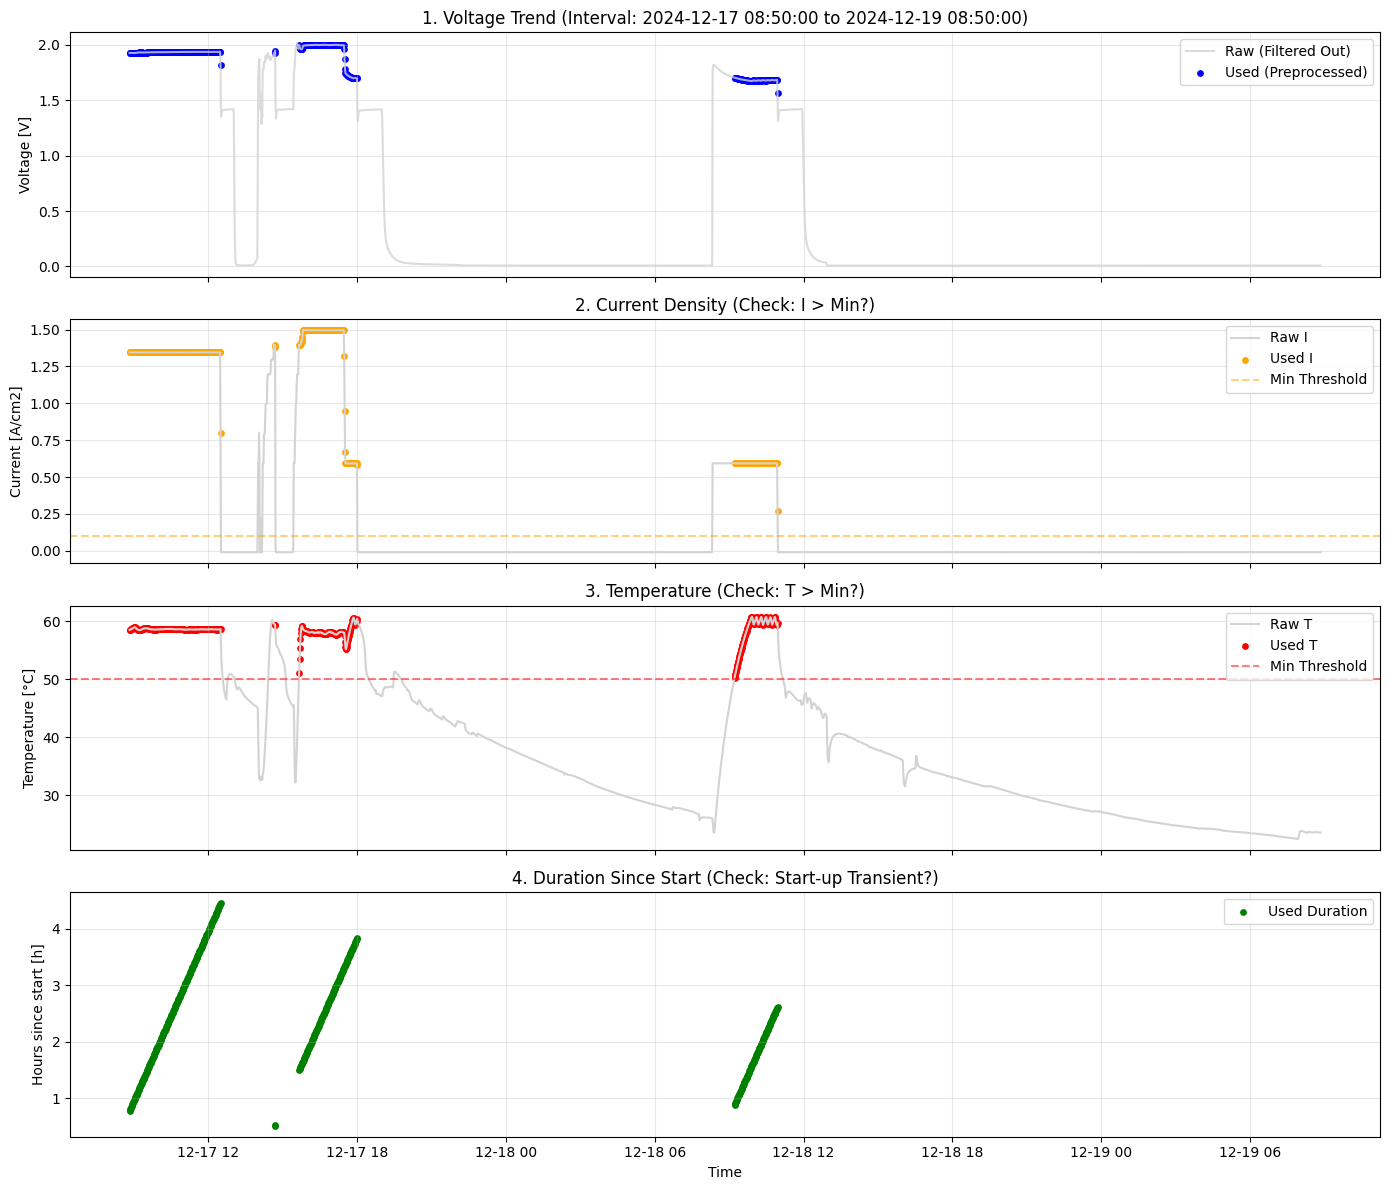


==================== 3-1. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature     log_h   voltage
currentDensity        1.000000    -0.041256  0.169467  0.995522
temperature          -0.041256     1.000000  0.250718 -0.086526
log_h                 0.169467     0.250718  1.000000  0.199813
voltage               0.995522    -0.086526  0.199813  1.000000

==================== 3-2. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature       IxT     log_h        I2
currentDensity        1.000000    -0.041256  0.998703  0.169467  0.997513
temperature          -0.041256     1.000000  0.006388  0.250718 -0.048921
IxT                   0.998703     0.006388  1.000000  0.179443  0.995338
log_h                 0.169467     0.250718  0.179443  1.000000  0.168240
I2                    0.997513    -0.048921  0.995338  0.168240  1.000000

==================== 3-3. Collinearity Check (Features) ===

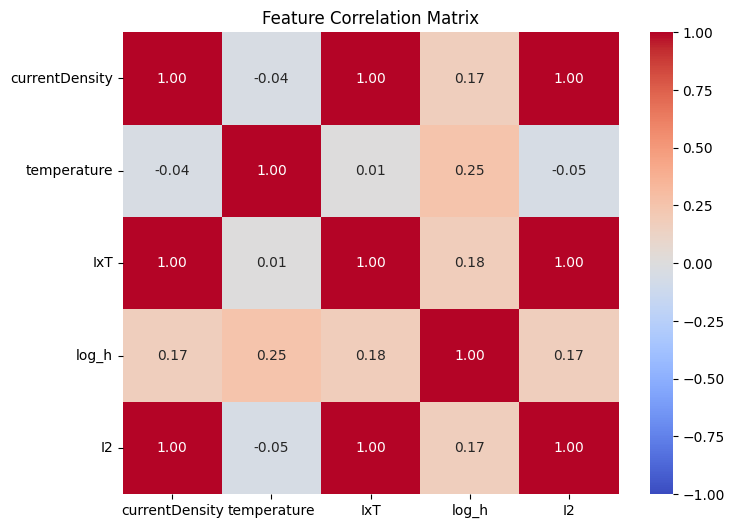


==================== 5. Pairwise Relationships (4D Scan) ====================


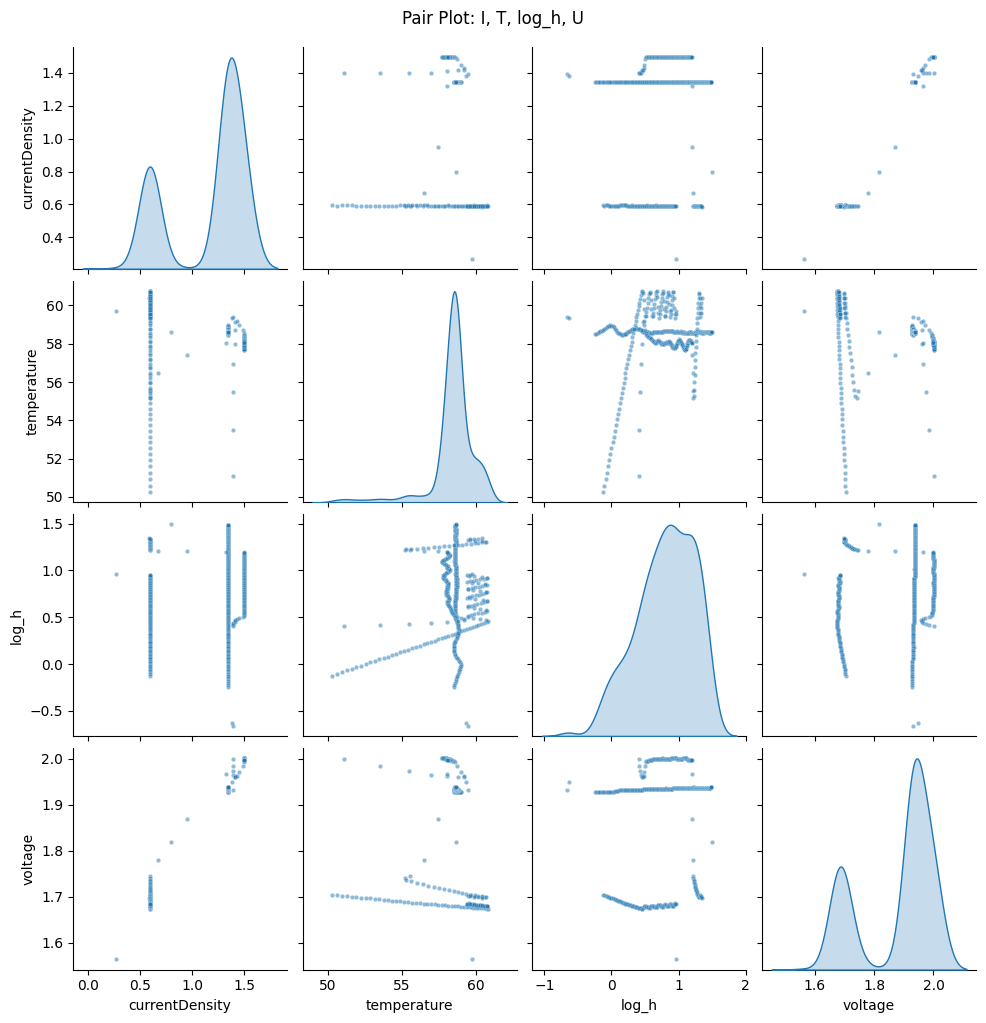


==================== 4. Interactive 3D Spatial Distribution ====================



==================== 6. Joint Distribution (Current vs Temp) ====================


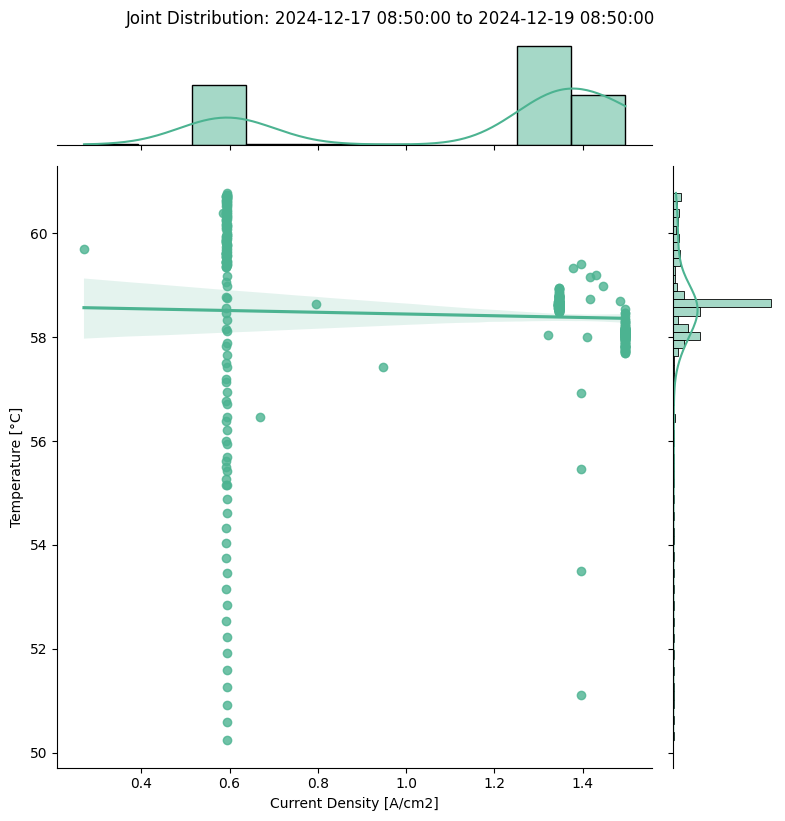


==================== 6. Joint Distribution (logh vs Temp) ====================


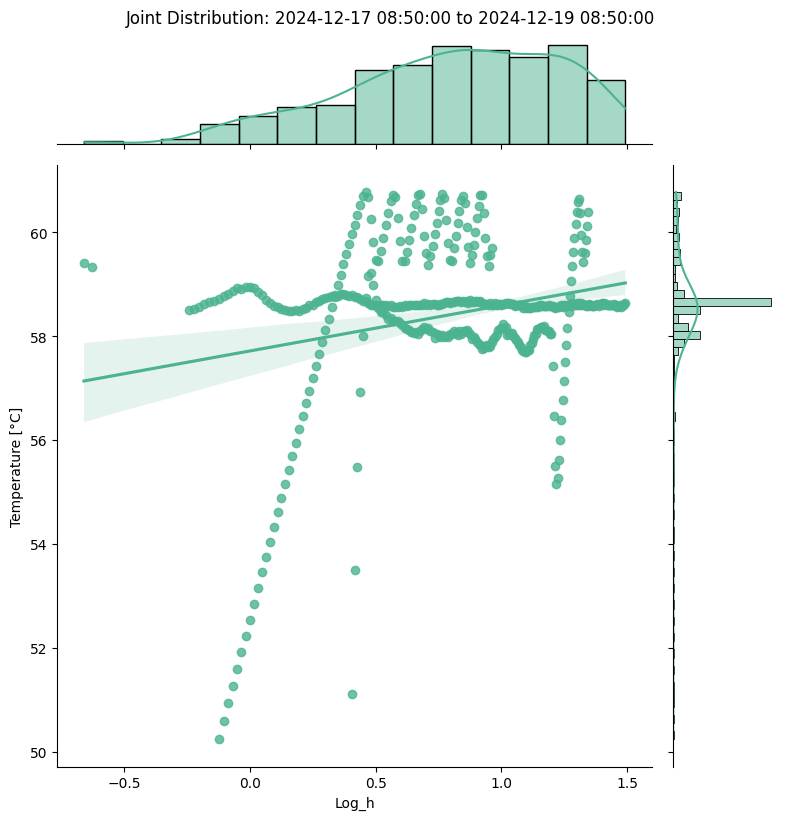

In [9]:
target_date = "2024-12-17"
print(f"Starting investigation for: {target_date}...")
investigator.run_full_diagnosis(target_date)

Starting investigation for: 2024-12-18...

Interval Locked: 2024-12-18 08:50:00 to 2024-12-20 08:50:00
Data Extraction Report:
  1. Raw Data Points:        2881
  2. Urc1 Preprocessed Pts:  466 (Used for fitting)
  3. Actual Data Coverage:   2024-12-18 08:50:00  ->  2024-12-20 08:50:00
      (Duration Covered:      48.0 hours)

==================== 1. Basic Statistics (Urc1 Preprocessed) ====================


,currentDensity,voltage,temperature,log_h
count,466.000000,466.000000,466.000000,466.000000
mean,0.592262,1.683223,59.003254,0.820461
std,0.021708,0.009883,2.429389,0.502228
min,0.254134,1.563570,50.166836,-0.143101
25%,0.593442,1.679480,59.396411,0.430147
50%,0.593783,1.682739,59.831636,0.780853
75%,0.593984,1.686797,60.397977,1.261060
max,0.594450,1.704674,60.774567,1.698669



==================== 2. Fitting Coefficients (Model Output) ====================
Found 1 results for this time. Showing the first one.


,c1,c1_se,c2,c2_se,c3,c3_se,c4,c4_se,c5,c5_se
Elyzer,2.015462,0.245193,-0.337906,0.003635,0.049968,0.000664,-2.81926,0.543493,0.35953,0.0025



Coefficient Quality Check:

Condition Number (Matrix Health): 2.00e+08

==================== 2. Time Series Investigation (4-Way Split) ====================


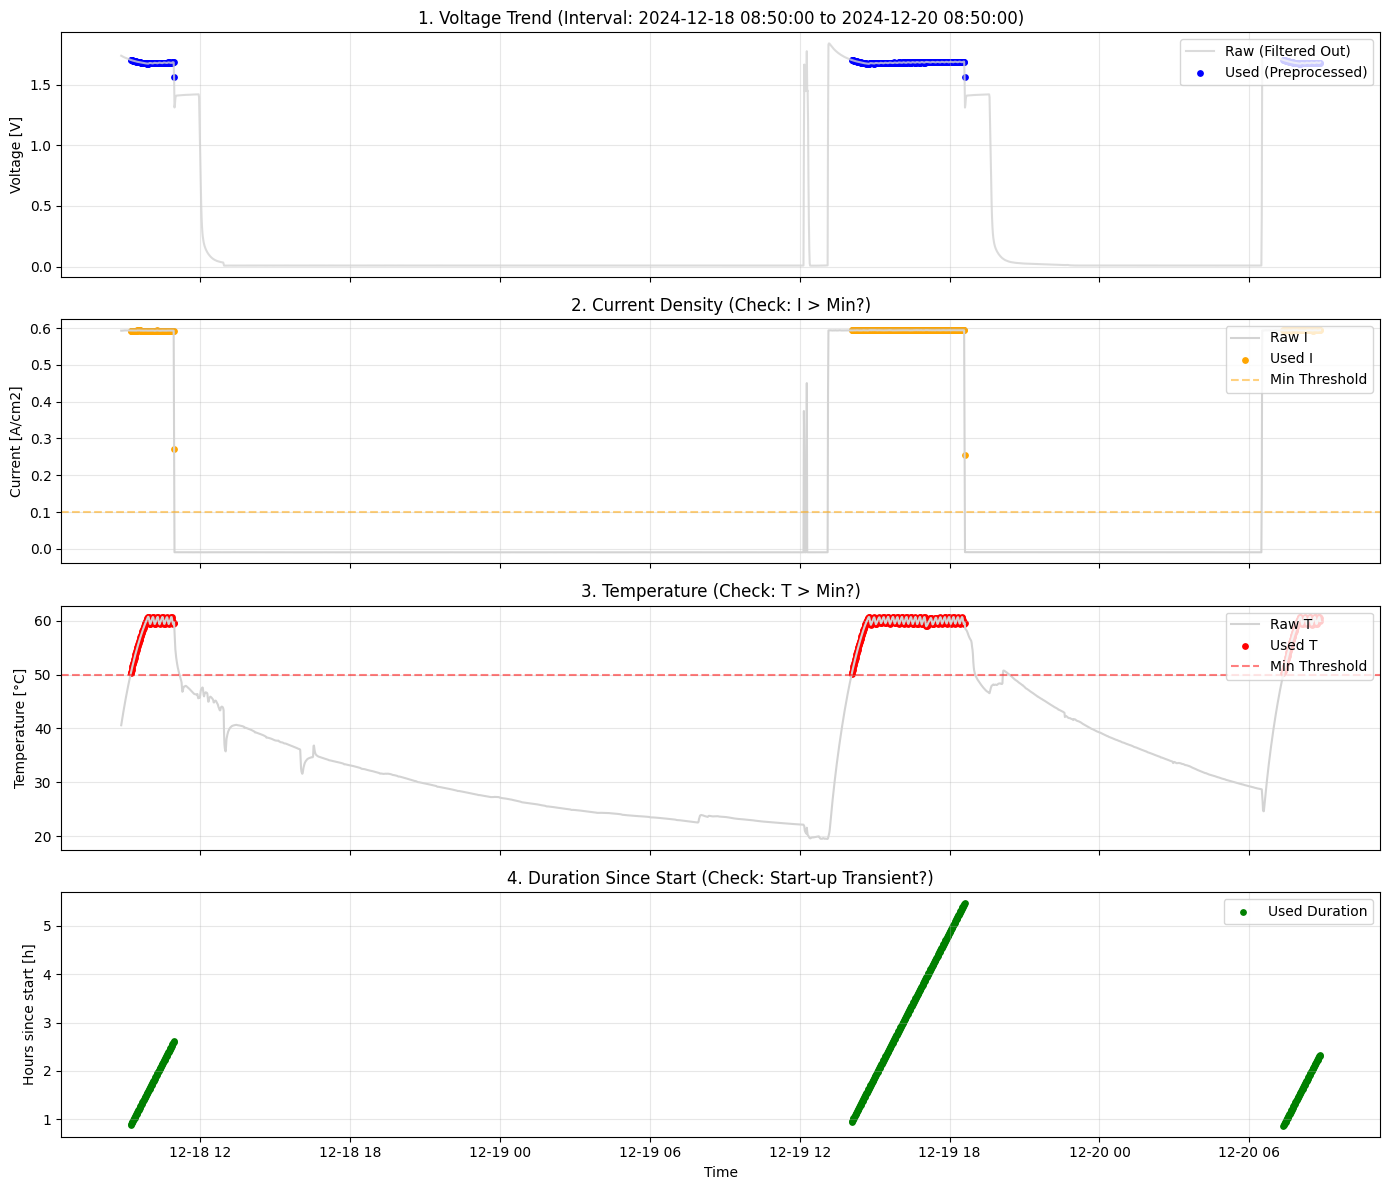


==================== 3-1. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature     log_h   voltage
currentDensity        1.000000    -0.014287 -0.059120  0.788193
temperature          -0.014287     1.000000  0.656394 -0.485321
log_h                -0.059120     0.656394  1.000000 -0.073293
voltage               0.788193    -0.485321 -0.073293  1.000000

==================== 3-2. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature       IxT     log_h        I2
currentDensity        1.000000    -0.014287  0.662470 -0.059120  0.999932
temperature          -0.014287     1.000000  0.739547  0.656394 -0.012716
IxT                   0.662470     0.739547  1.000000  0.451990  0.663603
log_h                -0.059120     0.656394  0.451990  1.000000 -0.055288
I2                    0.999932    -0.012716  0.663603 -0.055288  1.000000

==================== 3-3. Collinearity Check (Features) ===

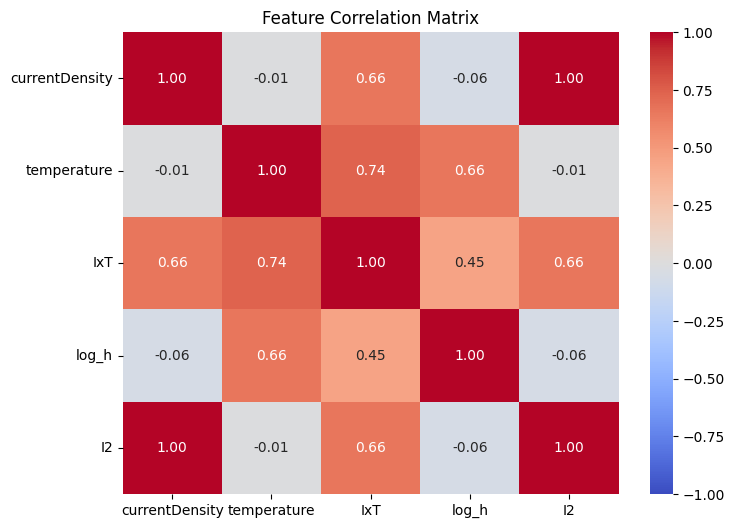


==================== 5. Pairwise Relationships (4D Scan) ====================


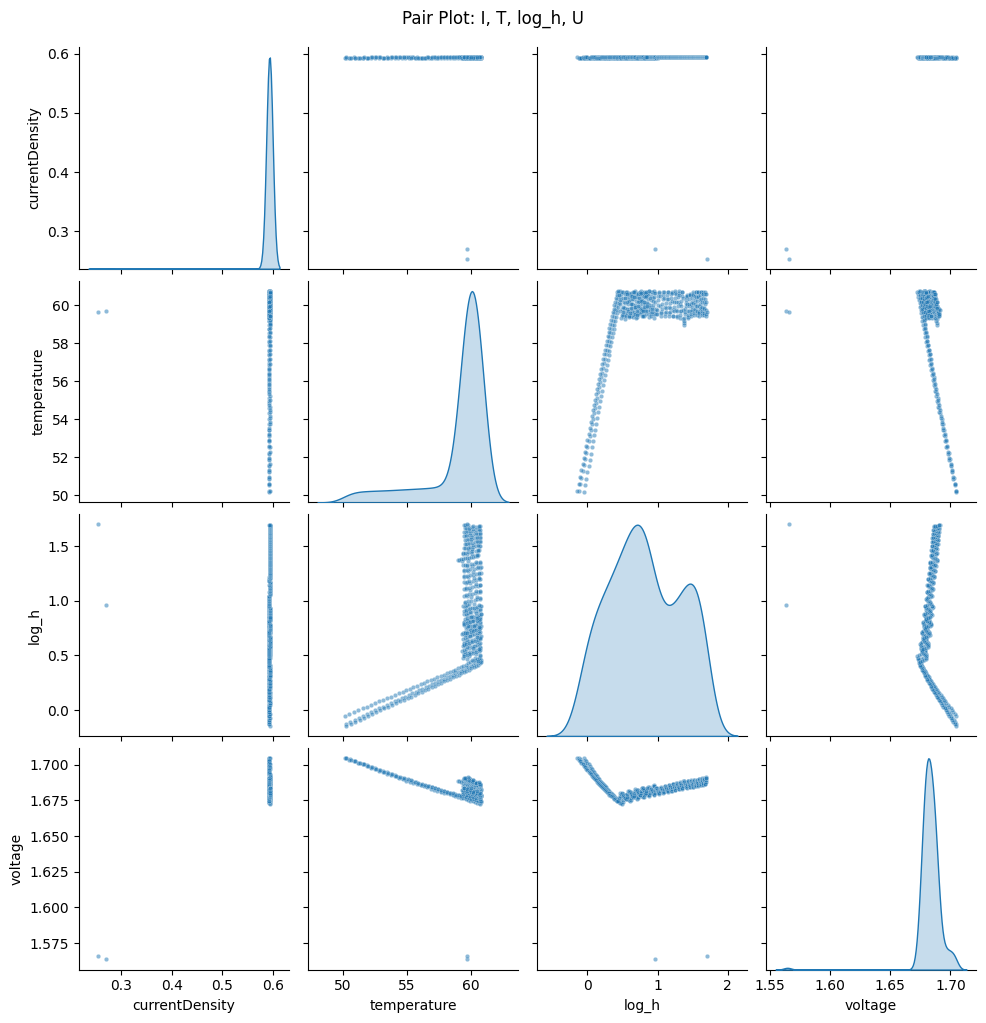


==================== 4. Interactive 3D Spatial Distribution ====================



==================== 6. Joint Distribution (Current vs Temp) ====================


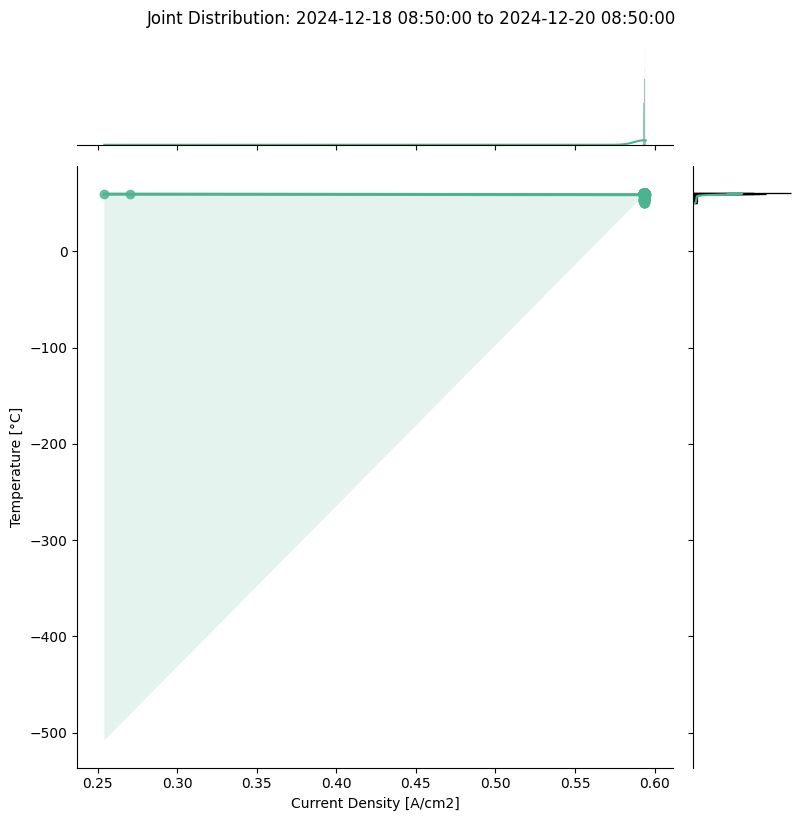


==================== 6. Joint Distribution (logh vs Temp) ====================


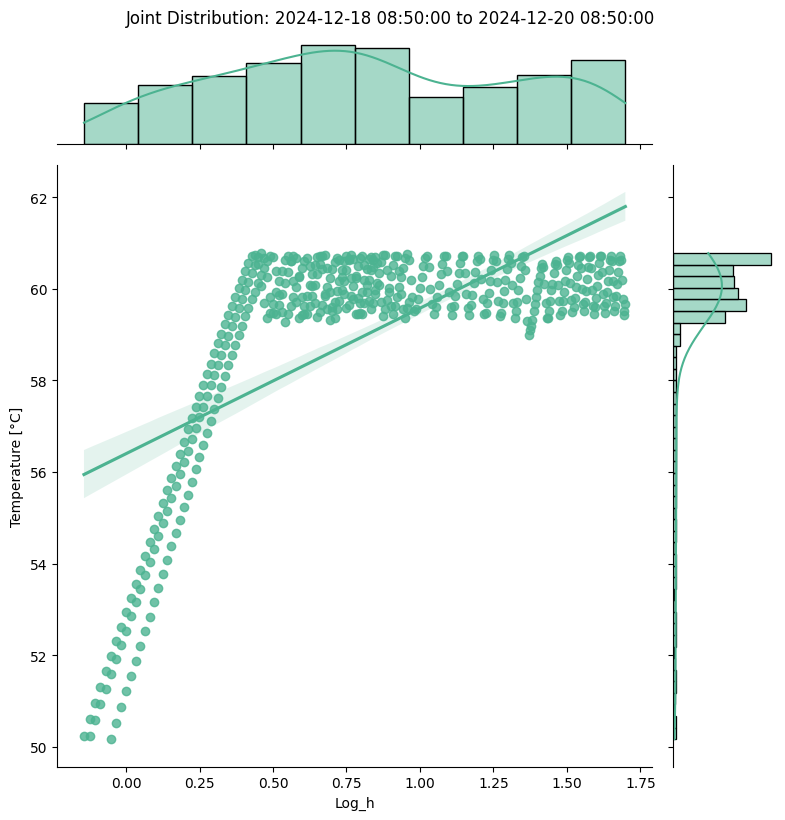

In [10]:
target_date = "2024-12-18"
print(f"Starting investigation for: {target_date}...")
investigator.run_full_diagnosis(target_date)

In [ ]:
log